# **Day 2 — Building CNNs & Transfer Learning**



---

### **What is Max Pooling?**

Max pooling consists of extracting windows from the input feature maps and outputting the max value of each channel. It is similar to convolution, except that instead of transforming local pathces via a learned linear transformation, they're *transformed via hardcoded max tensor operation*.

*Max pooling is an alternative and better way to achieve downsampling* ( in comparison to strides). Pooling **reduces computation**, **controls overfitting** and **makes the network robust to small input shifts**.

Pooling and convolution work together to *summarize an image into meaningfull features*.


---

### **Data Augmentation**

Data augmentation is **the process of generating more training data from existing training samples**, by *augmenting* the samples via a number of transformations - flips, rotations, zooms, shifts - that yield  believable looking images. During training, the same *picture is seen a only single time by the model*, this exposes the model to diverse aspects of the data and results in better generaliztion. However, it does not guarantee that the model will not experience overfitting, for that reason, a `Dropout` layer can be added to the model.

---

### **Transfer Learning**

Transfer Learning is a technique were **a model trained on one task is reused for a related task**. The model uses learned features from the first task, reduces training time for the new task, improves accuracy - while having less data -, and uses general features across tasks.

This approach is used when having a *limited amount of data*.

## **Building a CNN from Scratch**

In [18]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
os. environ['PTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/bag_classes.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, shutil
# The original line `shutil.rmtree("data/Bag Classes")` was removed to prevent premature deletion
# of the extracted directory. If 'Bag Classes' was extracted, it will be handled in the next cell.

In [ ]:


for old in ["images_raw", "sorted", "__MACOSX"]:
    path = os.path.join("data", old)
    if os.path.exists(path):
        shutil.rmtree(path)

# Check if 'Bag Classes' (with space) exists and rename it to 'Bag_Classes' (with underscore)
old_bag_classes_path = os.path.join("data", "Bag Classes")
new_bag_classes_path = os.path.join("data", "Bag_Classes")

if os.path.exists(old_bag_classes_path) and os.path.isdir(old_bag_classes_path):
    os.rename(old_bag_classes_path, new_bag_classes_path)
    print(f"Renamed '{old_bag_classes_path}' to '{new_bag_classes_path}'")

print(os.listdir("data"))

In [3]:
# verifying that the correct files are uploaded
base = "data/Bag_Classes"

if not os.path.exists(base):
    print(f"Error: Directory '{base}' not found. Please ensure the data is extracted correctly.")
else:
    for folder in os.listdir(base):
        path = os.path.join(base, folder)
        if os.path.isdir(path):
            print(folder, "->", len(os.listdir(path)), "images")

Paper Bag Images -> 5000 images
Plastic Bag Images -> 5000 images
Garbage Bag Images -> 5000 images


In [4]:
import tensorflow as tf
# train/validation split
train_ds = tf.keras.utils.image_dataset_from_directory(
    base,
    image_size = (128, 128),
    batch_size = 32,
    label_mode = "categorical",
    validation_split = 0.2,
    subset = "training",
    seed = SEED
    shuffle = True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base,
    image_size = (128, 128),
    batch_size = 32,
    label_mode = "categorical",
    validation_split = 0.2,
    subset = "validation",
    seed = 42
)

print(train_ds.class_names)

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.
['Garbage Bag Images', 'Paper Bag Images', 'Plastic Bag Images']


#### **Normalization and optimizing pipeline**

Images come in pixel values (0-255). Neural networks train better when iput values are small (0 - 1 / -1 - 1). Normalizing keeps the comparison between the 3 (to be built models) valid.

In [5]:
normalization_layer = tf.keras.layers. Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)# speed the reading time
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

In [6]:
import time
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Convolutional layer -> Max Pooling -> Flattening out -> Dense layer
# Convolutional layer: detects simple/complex patterns
# Max pooling: reduce spatial dimensions
# Flatten: flatten the data to 1D to be processed by the dense layer
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")

])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
start_time = time.time()
history_baseline = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs = 15
)
training_time_baseline = time.time() - start_time
print(f" Baseline training time: {training_time_baseline:.1f} seconds")

import pickle
with open("history_baseline.pk1", "wb") as f:
  pickle.dump(history_baseline.history, f)

print("Final validation accuracy:", history_baseline.history["val_accuracy"][-1])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7847 - loss: 0.5338 - val_accuracy: 0.8723 - val_loss: 0.3523
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8929 - loss: 0.2866 - val_accuracy: 0.8800 - val_loss: 0.3076
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9250 - loss: 0.2049 - val_accuracy: 0.8977 - val_loss: 0.2958
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9480 - loss: 0.1413 - val_accuracy: 0.9047 - val_loss: 0.3028
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9597 - loss: 0.1121 - val_accuracy: 0.9047 - val_loss: 0.3553
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9725 - loss: 0.0816 - val_accuracy: 0.9080 - val_loss: 0.3846
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9804 - loss: 0.0589 - val_accuracy: 0.8897 - val_loss: 0.5718
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9833 - loss: 0.0498 - val_acc

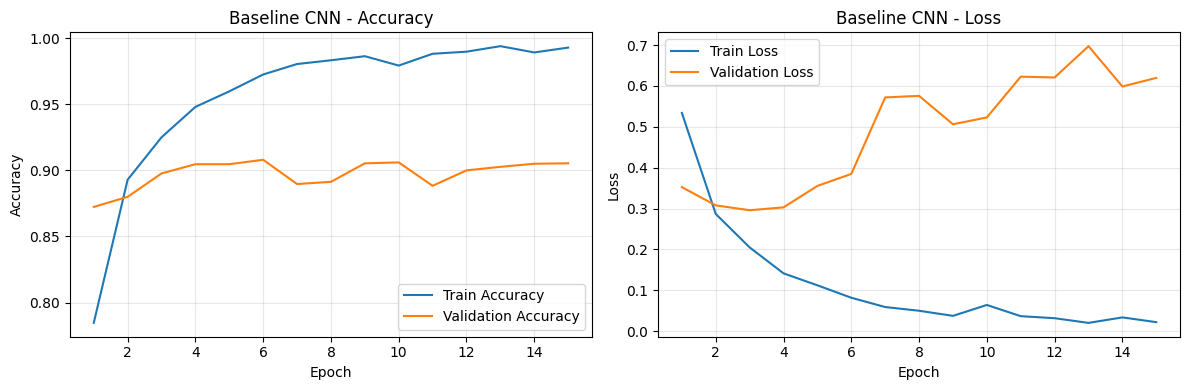

In [7]:
import matplotlib.pyplot as plt

acc = history_baseline.history["accuracy"]
val_acc = history_baseline.history["val_accuracy"]
loss = history_baseline.history["loss"]
val_loss = history_baseline.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].plot(epochs_range, acc, label="Train Accuracy")
axes[0].plot(epochs_range, val_acc,  label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline CNN - Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, loss, label="Train Loss")
axes[1].plot(epochs_range, val_loss, label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline CNN - Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Observations:**


*   The first epoch accuracy results ( train - 78.2% / validation - 85.5%) compared to the last epoch results ( train - 99.3% / validation - 89.9%)

* The baseline CNN reaches *99.3% training accuracy* by epoch 15 while *validation accuracy gradually grows from 89% to 90%* . This *widening gap* combined with *validation loss steadily rising form aorund 30% to 71%* while the *validation accuracy shows marginal improvement* is a strong indicator of **overfitting**.

*   The results shows that **the model is memorizing results** rather than recognising patterns. This issue can be specifically *solved with* **Data Augmentation** as mentioned earlier in the notebook.



## **Data Augmentation**

In [8]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

augment = Sequential([
RandomFlip("horizontal"),
RandomRotation(0.1),
RandomZoom(0.1),
])

model_aug = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")

])

model_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
start_time = time.time()

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs = 15
)
training_time_aug = time.time() - start_time
print(f" Data Augmentation training time: {training_time_aug:.1f} seconds")
import pickle
with open("history_aug.pk1", "wb") as f:
  pickle.dump(history_aug.history, f)

print("Final validation accuracy:", history_aug.history["val_accuracy"][-1])

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8042 - loss: 0.5034 - val_accuracy: 0.8730 - val_loss: 0.3366
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8979 - loss: 0.2767 - val_accuracy: 0.9023 - val_loss: 0.2651
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9327 - loss: 0.1858 - val_accuracy: 0.9007 - val_loss: 0.2810
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9504 - loss: 0.1486 - val_accuracy: 0.8993 - val_loss: 0.3164
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9656 - loss: 0.1008 - val_accuracy: 0.9083 - val_loss: 0.3123
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9726 - loss: 0.0804 - val_accuracy: 0.8963 - val_loss: 0.3712
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9803 - loss: 0.0588 - val_accuracy: 0.9023 - val_loss: 0.3985
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9803 - loss: 0.0568 - val_acc

#### **Augmented CNN Observations**



*  Applying random transformations during training ***slightly improved the Final validation accuracy*** from 89.8% to 91.7%.

*  The *train-validation accuracy gap narrowed a little*, suggesting augmentaition provided a regularizing effect.

* *Overfitting is still clearly present*, training accuracy  reaches 99
5 at epoch 15 and validation loss climbs steadily from 31% to 52% despite validation accuracy being steady.

* Augmentation alone wasn't enough to resolve the images of bags. Flips, rotations and zooms only added little new information. This rises interest as to *what Transfer learning could possibly add to the accuracy of the model*.



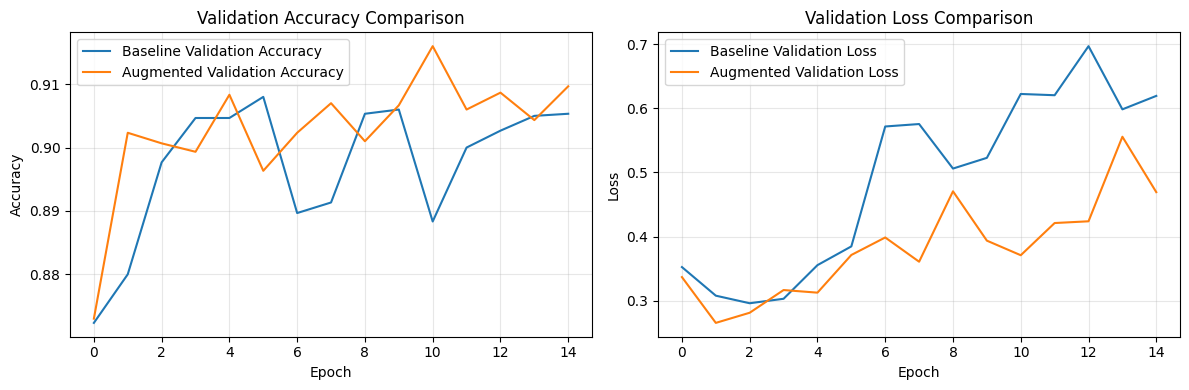

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_baseline.history["val_accuracy"], label="Baseline Validation Accuracy")
plt.plot(history_aug.history["val_accuracy"], label="Augmented Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_baseline.history["val_loss"], label="Baseline Validation Loss")
plt.plot(history_aug.history["val_loss"], label="Augmented Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

## **Baseline vs. Augmented Comparison**

1.   **Data augmentation added a small contribution and improvement**; final validation accuracy improved by ~1.2% and validation loss by ~0.2%.

2.   The validation accuracy and loss curves for the **augmented model showed more stability** compared to the baseline - avoiding sharp dips/climbs.

*The improvement is modest relative to the effort , as the model still shows overfitting.*



## **Transfer Learning**

#### **Building an unnormalized dataset**

In [10]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# train/validation split
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    "data/Bag_Classes",
    image_size = (128, 128),
    batch_size = 32,
    label_mode = "categorical",
    validation_split = 0.2,
    subset = "training",
    seed = 42
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    "data/Bag_Classes",
    image_size = (128, 128),
    batch_size = 32,
    label_mode = "categorical",
    validation_split = 0.2,
    subset = "validation",
    seed = 42
)

train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.


#### **Building a Model with Frozen MobileNetV2 Base**

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=(128,128,3))
base_model.trainable = False
num_classes = 3

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(), #better than flatten- fewer params/less overfitting
    Dense(num_classes, activation="softmax")
])


model_tl.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#### **Training & Time**

In [12]:
import time
import pickle

start_time = time.time()
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data = val_ds_tl,
    epochs=15
)

training_time_tl = time.time() - start_time
print(f" Transfer Learning training time: {training_time_tl:.1f} seconds")

with open("history_tl.pk1", "wb") as f:
  pickle.dump(history_tl.history, f)

print("Final Validation Accuracy - Transfer Learning:", history_tl.history["val_accuracy"][-1])


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 52s 95ms/step - accuracy: 0.9316 - loss: 0.1775 - val_accuracy: 0.9640 - val_loss: 0.0998
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9695 - loss: 0.0846 - val_accuracy: 0.9697 - val_loss: 0.0823
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9775 - loss: 0.0645 - val_accuracy: 0.9720 - val_loss: 0.0748
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9832 - loss: 0.0525 - val_accuracy: 0.9720 - val_loss: 0.0717
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9858 - loss: 0.0441 - val_accuracy: 0.9723 - val_loss: 0.0709
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9894 - loss: 0.0378 - val_accuracy: 0.9723 - val_loss: 0.0710
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9915 - loss: 0.0328 - val_accuracy: 0.9733 - val_loss: 0.0714
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9933 - loss: 0.0288 - val_acc

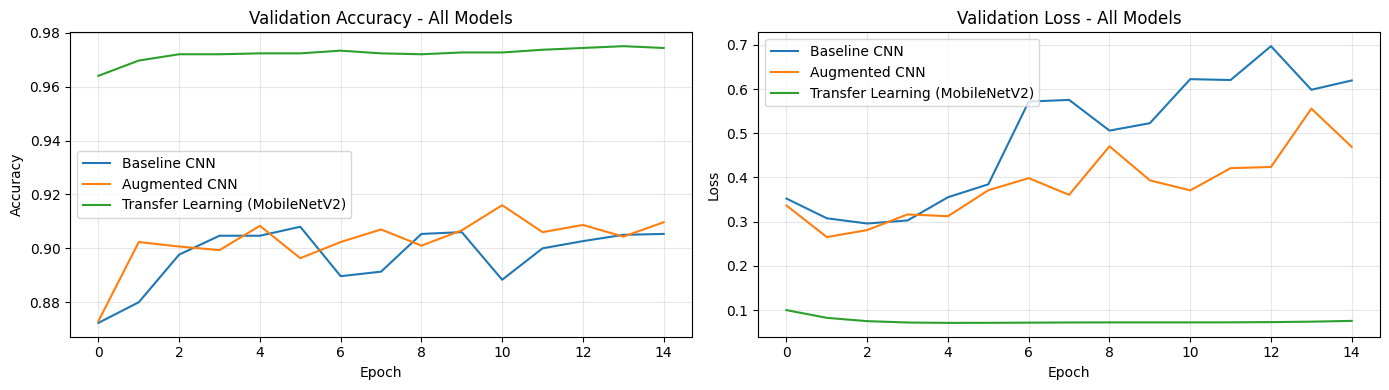

In [17]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(history_baseline.history["val_accuracy"], label="Baseline CNN")
plt.plot(history_aug.history["val_accuracy"], label="Augmented CNN")
plt.plot(history_tl.history["val_accuracy"], label="Transfer Learning (MobileNetV2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy - All Models")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_baseline.history["val_loss"], label="Baseline CNN")
plt.plot(history_aug.history["val_loss"], label="Augmented CNN")
plt.plot(history_tl.history["val_loss"], label="Transfer Learning (MobileNetV2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss - All Models")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

#### **Transfer Learning Observations**

Using frozen MobileNetV2 base pre-trained on ImageNet  with only a GlobalAveragePooling2D + Dense(3, softmax) head trained on top, achieved 97% validation accuracy, substantially higher than the baseline and augmented from-scratch CNNs.



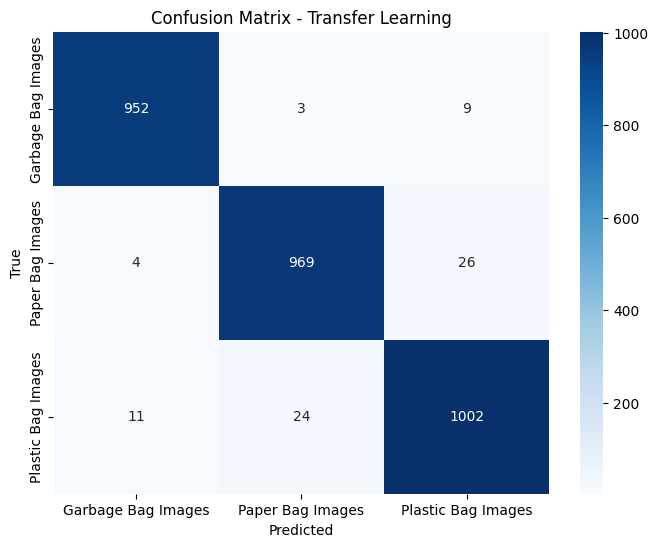

                    precision    recall  f1-score   support

Garbage Bag Images       0.98      0.99      0.99       964
  Paper Bag Images       0.97      0.97      0.97       999
Plastic Bag Images       0.97      0.97      0.97      1037

          accuracy                           0.97      3000
         macro avg       0.97      0.97      0.97      3000
      weighted avg       0.97      0.97      0.97      3000



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds_tl:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(model_tl.predict(images, verbose=0), axis=1))


y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names=["Garbage Bag Images", "Paper Bag Images", "Plastic Bag Images"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Transfer Learning")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

#### **Transfer Learning Evaluation**

The transfer learning model **classifies all three categories well**. Garbage bags are the easiest to distinguish with 12 total misclassifications. I assume those missed ones were due to the black appearance of the garbage bags which distinguishes it form the other two categories.

The **main confusion was between the paper and plastic bags** - 26 paper bags were classified as plastic, 24 plastic classified as paper - which counts for the *majority of errors*. This makes sense as some **plastic and paper bags share similar characteristics**. On the other hand, confusing them with garbage bags is rare due to previously mentioned reasons.

Overall, the model shows **no systematic neglecting/dominance** for all classes showing **balanced precision and recall** around 0.97-0.99. This score supports that the accuracy score recorded by Transfer Learning reflects strong, well-distributed performance for all classes equally.

In [21]:
summary = pd.DataFrame({
    "Model": ["Baseline CNN", "Augmented CNN", "Transfer Learning (MobileNetV2)"],
    "Fianl Train Accuracy": [
        history_baseline.history["accuracy"][-1],
        history_aug.history["accuracy"][-1],
        history_tl.history["accuracy"][-1]
        ],
    "Final Validation Accuracy": [
        history_baseline.history["val_accuracy"][-1],
        history_aug.history["val_accuracy"][-1],
        history_tl.history["val_accuracy"][-1]
        ],
    "Final Validation Loss": [
        history_baseline.history["val_loss"][-1],
        history_aug.history["val_loss"][-1],
        history_tl.history["val_loss"][-1]
        ],
    "Train/Validation Accuracy Gap":[
        history_baseline.history["accuracy"][-1] - history_baseline.history["val_accuracy"][-1],
        history_aug.history["accuracy"][-1] - history_aug.history["val_accuracy"][-1],
        history_tl.history["accuracy"][-1] - history_tl.history["val_accuracy"][-1]
    ],
    "Training Time": [
        training_time_baseline,
        training_time_aug,
        training_time_tl],
    "Trainable Parameters": [
        model.count_params(),
        model_aug.count_params(),
        sum(np.prod(w.shape) for w in model_tl.trainable_weights)
    ],

})

summary

,Model,Fianl Train Accuracy,Final Validation Accuracy,Final Validation Loss,Train/Validation Accuracy Gap,Training Time,Trainable Parameters
0,Baseline CNN,0.992833,0.905333,0.619554,0.087500,97.387627,3706051
1,Augmented CNN,0.995833,0.909667,0.469259,0.086167,88.797580,3706051
2,Transfer Learning (MobileNetV2),0.998000,0.974333,0.075411,0.023667,123.095436,3843


## **Final Comparison**

Transfer Learning performed best by a wide margin - 97% validation accuracy, roughly 6 - 7  points higher than the other two models while showing the smallest overfitting gap  and the lowest, most stable validation loss. This was achieved with the smallest number of trainable parameters among the three models.

Trasnsfer learning took the longest training time with the first epoch consuming majority if the time.

**Reproducability Note:**
Results may vary by 1-2% between runs due to random weight initializations, data shufflinh order and other factors, Global seeding was added for future runs .

**Conclusion:**
For this bag classification dataset, transfer learning with a frozen pre-trained model clearly outperformed  training CNN from scratch. While using dramatically  ferwer trainable parameters and generalizing far better on unseen data.